In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from scipy.cluster.hierarchy import linkage, fcluster

# ------------------------------
# User-controlled "large value" threshold
# All rows with target >= this quantile are marked interesting
high_value_quantile = 0.94  # top 5%; lower this to get more "interesting" rows
# ------------------------------

# Step 1: Download/Load the California Housing dataset and save as CSV
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# For adaptability: specify the regression target column name
target_col = 'MedHouseVal'

# Save to CSV
df.to_csv('california_housing.csv', index=False)

# Step 2: Read the data from CSV (simulates downloading and reading)
df = pd.read_csv('california_housing.csv')

# Extract the target as a 1D array reshaped for clustering
X = df[target_col].values.reshape(-1, 1)

# Step 3-5: Perform hierarchical clustering on the target only
method = 'single'
Z = linkage(X, method=method)

# Automatically determine threshold: find the largest jump in merge heights
heights = Z[:, 2]
diffs = np.diff(heights)
if len(diffs) > 0:
    max_diff_idx = np.argmax(diffs)
    threshold = heights[max_diff_idx]  # Cut before the largest gap
else:
    threshold = np.max(heights) if len(heights) > 0 else 0  # Fallback for small data

# Form flat clusters based on the distance threshold
clusters = fcluster(Z, t=threshold, criterion='distance')

# Identify the largest cluster (the "normal" dense group)
unique_clusters, counts = np.unique(clusters, return_counts=True)
largest_cluster_label = unique_clusters[np.argmax(counts)]

# Base: interesting if NOT in largest cluster
interesting_mask = (clusters != largest_cluster_label)

# ---------------------------------------
# NEW: enforce that very large values are interesting
# ---------------------------------------
high_value_cutoff = df[target_col].quantile(high_value_quantile)
interesting_mask |= df[target_col] >= high_value_cutoff

# Step 6: Create new column
df['is_interesting_subgroup'] = interesting_mask

# Step 7: Save the updated DataFrame as a new CSV
df.to_csv('california_housing_with_interesting.csv', index=False)

# Optional: Print summary for verification
print(f"Threshold (clustering) used: {threshold}")
print(f"Largest cluster label: {largest_cluster_label}")
print(f"High-value quantile: {high_value_quantile}")
print(f"High-value cutoff: {high_value_cutoff}")
print(f"Number of interesting rows: {df['is_interesting_subgroup'].sum()}")
print("Updated CSV saved as 'california_housing_with_interesting.csv'")


Threshold (clustering) used: 0.025009999999999977
Largest cluster label: 1
High-value quantile: 0.94
High-value cutoff: 4.521
Number of interesting rows: 1246
Updated CSV saved as 'california_housing_with_interesting.csv'


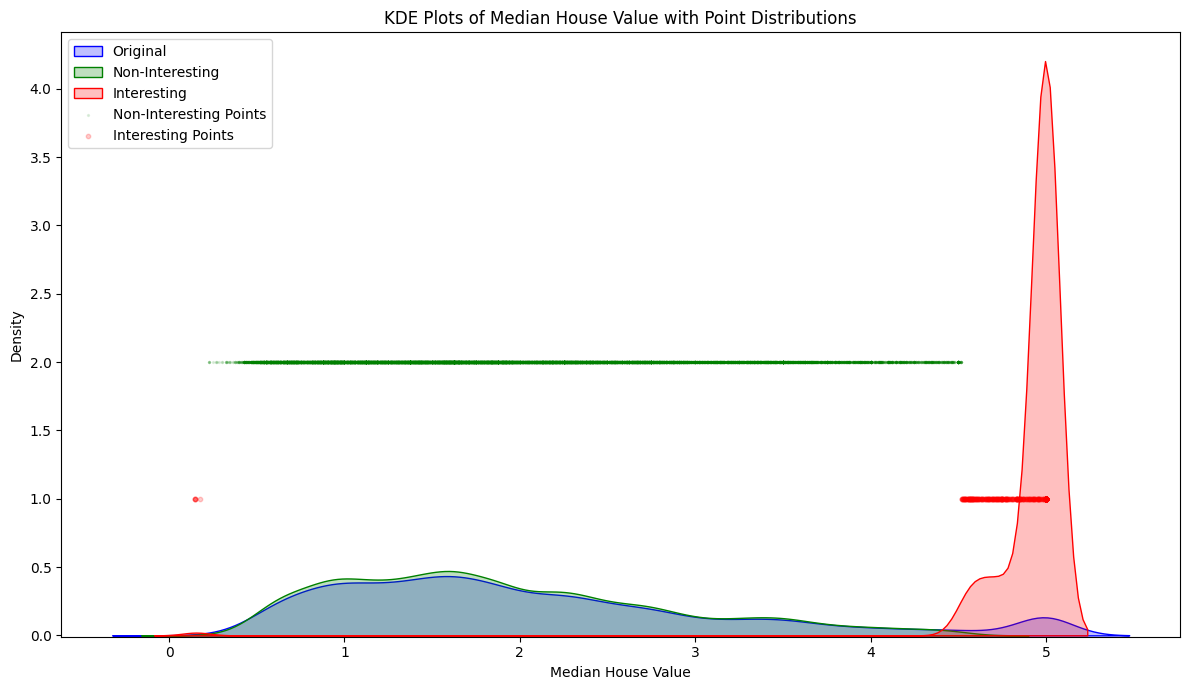

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Read CSV
df = pd.read_csv('california_housing_with_interesting.csv')

target_col = 'MedHouseVal'

# Subsets
interesting = df[df['is_interesting_subgroup'] == True]
non_interesting = df[df['is_interesting_subgroup'] == False]

plt.figure(figsize=(12, 7))

# KDE plots
sns.kdeplot(df[target_col], color='blue', fill=True, alpha=0.25, label='Original')
sns.kdeplot(non_interesting[target_col], color='green', fill=True, alpha=0.25, label='Non-Interesting')
sns.kdeplot(interesting[target_col], color='red', fill=True, alpha=0.25, label='Interesting')

# ----------------------------------------------------
# SCATTER POINTS ON OFFSET Y-AXES
# ----------------------------------------------------

# Offsets to stack the points visually
y_noninteresting = np.full(len(non_interesting), 2.)   # slight shift below x-axis
y_interesting    = np.full(len(interesting),  1.)       # slight shift above x-axis

# Plot scatter points
plt.scatter(
    non_interesting[target_col],
    y_noninteresting,
    color='green',
    alpha=0.1,
    s=2,
    label='Non-Interesting Points'
)

plt.scatter(
    interesting[target_col],
    y_interesting,
    color='red',
    alpha=0.2,
    s=10,
    label='Interesting Points'
)

# -----------------------------------------
# Formatting
# -----------------------------------------
plt.title("KDE Plots of Median House Value with Point Distributions")
plt.xlabel("Median House Value")
plt.ylabel("Density")

# Hide y values around 0 (scatter offsets)
plt.ylim(-0.01, None)

# Avoid duplicate label entries
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys())

plt.tight_layout()
plt.savefig("house_value_kde_improved.jpg", dpi=300)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import _tree  # <-- added
import yaml

# 1) Read the new CSV file
data_path = 'california_housing_with_interesting.csv'  # Upload to Colab or place in working dir
df = pd.read_csv(data_path)

target_col = 'is_interesting_subgroup'

# EXCLUDE both the target and the original regression target "MedHouseVal"
feature_cols = [c for c in df.columns if c not in [target_col, 'MedHouseVal']]

X = df[feature_cols].values
y = df[target_col].astype(int).values  # binary labels 0/1


# -------------------------------------------------------------------
# Prune subtrees whose leaves all predict the same class
# -------------------------------------------------------------------
def prune_pure_subtrees(tree: DecisionTreeClassifier) -> None:
    """
    In-place pruning: if all leaves in a subtree predict the same class,
    collapse the whole subtree into a single leaf node without
    changing the tree's predictions.
    """
    tree_ = tree.tree_

    def recurse(node_id: int):
        # Leaf -> return its predicted class index
        if tree_.children_left[node_id] == -1 and tree_.children_right[node_id] == -1:
            value = tree_.value[node_id][0]
            class_index = int(np.argmax(value))
            return {class_index}

        # Recurse into children
        left_id = tree_.children_left[node_id]
        right_id = tree_.children_right[node_id]

        left_classes = recurse(left_id)
        right_classes = recurse(right_id)

        union = left_classes | right_classes

        # If all leaves below predict the same class, prune here
        if len(union) == 1:
            tree_.children_left[node_id] = -1
            tree_.children_right[node_id] = -1
            tree_.feature[node_id] = _tree.TREE_UNDEFINED
            tree_.threshold[node_id] = -2.0
            # Keep tree_.value[node_id] as-is; argmax stays consistent
        return union

    recurse(0)


# -------------------------------------------------------------------
# Count decision questions in a tree
# -------------------------------------------------------------------
def count_questions(tree: DecisionTreeClassifier) -> int:
    tree_ = tree.tree_
    children_left = tree_.children_left
    children_right = tree_.children_right

    # Count only reachable internal nodes (questions) from the root
    def dfs(node_id: int) -> int:
        if node_id == -1:
            return 0
        # leaf
        if children_left[node_id] == -1 and children_right[node_id] == -1:
            return 0
        # internal node
        return 1 + dfs(children_left[node_id]) + dfs(children_right[node_id])

    return int(dfs(0))


# -------------------------------------------------------------------
# YAML export including human-readable questions
# -------------------------------------------------------------------
def tree_to_dict(tree: DecisionTreeClassifier, feature_names):
    """
    Export a sklearn DecisionTreeClassifier into a nested dict for YAML,
    including a readable 'question' field.
    """
    tree_ = tree.tree_
    feature = tree_.feature
    threshold = tree_.threshold

    def recurse(node_id: int):
        # Leaf node
        if tree_.children_left[node_id] == -1 and tree_.children_right[node_id] == -1:
            value = tree_.value[node_id][0]
            class_index = int(np.argmax(value))
            class_label = int(tree.classes_[class_index])
            return {
                'leaf_prediction': class_label,
                'class_counts': value.tolist(),
            }

        # Internal decision node
        feat_name = feature_names[feature[node_id]]
        thresh = float(threshold[node_id])

        return {
            'question': f"{feat_name} <= {thresh}",
            'feature': feat_name,
            'threshold': thresh,
            'left': recurse(tree_.children_left[node_id]),
            'right': recurse(tree_.children_right[node_id]),
        }

    return recurse(0)


# -------------------------------------------------------------------
# Build + evaluate forest (small random forest with constraints)
# -------------------------------------------------------------------
def build_and_evaluate_forest(seed: int):
    """
    Build a small random forest and evaluate on training data.
    For each seed:
      - maximal number of trees ~ Uniform{1,...,10}
      - maximal number of questions per tree ~ Uniform{2,...,10}
    Forest rule: interesting if ANY tree predicts interesting.
    Deterministic for a given seed.
    """
    rng = np.random.RandomState(seed)

    n_samples = X.shape[0]

    # Draw per-seed maxima (deterministic for the seed)
    max_n_trees = rng.randint(1, 11)   # 1..10 inclusive
    max_questions = rng.randint(2, 11) # 2..10 inclusive

    n_trees = max_n_trees

    trees = []
    tree_accuracies = []
    tree_question_counts = []

    print(f"Seed {seed} - max_n_trees={max_n_trees}, max_questions_per_tree={max_questions}")

    for tree_idx in range(n_trees):
        # Bootstrap sample
        bootstrap_indices = rng.choice(n_samples, size=n_samples, replace=True)
        X_boot = X[bootstrap_indices]
        y_boot = y[bootstrap_indices]

        # Each tree has at most max_questions internal decision nodes.
        # Using max_leaf_nodes = max_questions + 1 ensures internal nodes <= max_questions
        tree_random_state = rng.randint(0, 1_000_000)
        clf = DecisionTreeClassifier(
            max_leaf_nodes=max_questions + 1,
            random_state=tree_random_state,
        )
        clf.fit(X_boot, y_boot)

        # Prune subtrees that don't change predictions
        prune_pure_subtrees(clf)

        # Evaluate tree on full training set
        y_pred_tree = clf.predict(X)
        acc_tree = (y_pred_tree == y).mean()

        # Count questions
        n_questions = count_questions(clf)

        print(f"  Tree {tree_idx}: accuracy={acc_tree:.4f}, questions={n_questions}")

        # Store results
        trees.append(clf)
        tree_accuracies.append(acc_tree)
        tree_question_counts.append(n_questions)

        # Save YAML tree
        tree_dict = tree_to_dict(clf, feature_names=feature_cols)
        tree_filename = f"tree_seed{seed}_tree{tree_idx}.yml"
        with open(tree_filename, 'w') as f:
            yaml.dump(tree_dict, f)

    # -------------------------------------------------------------------
    # Forest prediction = OR of all trees' predictions
    # -------------------------------------------------------------------
    all_tree_preds = []
    for clf in trees:
        preds = clf.predict(X)
        all_tree_preds.append(preds.astype(bool))

    pred_matrix = np.vstack(all_tree_preds)
    forest_pred = np.any(pred_matrix, axis=0).astype(int)

    forest_accuracy = (forest_pred == y).mean()
    total_questions = int(np.sum(tree_question_counts))

    print(f"Seed {seed} - Forest accuracy={forest_accuracy:.4f}, "
          f"n_trees={n_trees}, total_questions={total_questions}")
    print("-" * 60)

    return {
        'seed': seed,
        'forest_accuracy': forest_accuracy,
        'n_trees': n_trees,
        'total_questions': total_questions,
    }


# -------------------------------------------------------------------
# Run for 100 seeds and save results
# -------------------------------------------------------------------
results = []
seeds = list(range(1000))  # 0..99

for s in seeds:
    metrics = build_and_evaluate_forest(s)
    results.append(metrics)

results_df = pd.DataFrame(results)
results_df.to_csv('results.csv', index=False)

print("\nSummary of forests:")
print(results_df)


Die letzten 5000 Zeilen der Streamingausgabe wurden abgeschnitten.
  Tree 4: accuracy=0.9554, questions=4
  Tree 5: accuracy=0.9593, questions=3
  Tree 6: accuracy=0.9535, questions=4
  Tree 7: accuracy=0.9593, questions=3
  Tree 8: accuracy=0.9547, questions=2
  Tree 9: accuracy=0.9586, questions=3
Seed 415 - Forest accuracy=0.9523, n_trees=10, total_questions=26
------------------------------------------------------------
Seed 416 - max_n_trees=7, max_questions_per_tree=5
  Tree 0: accuracy=0.9592, questions=3
  Tree 1: accuracy=0.9535, questions=4
  Tree 2: accuracy=0.9591, questions=3
  Tree 3: accuracy=0.9553, questions=2
  Tree 4: accuracy=0.9594, questions=3
  Tree 5: accuracy=0.9589, questions=3
  Tree 6: accuracy=0.9559, questions=2
Seed 416 - Forest accuracy=0.9540, n_trees=7, total_questions=20
------------------------------------------------------------
Seed 417 - max_n_trees=4, max_questions_per_tree=5
  Tree 0: accuracy=0.9548, questions=2
  Tree 1: accuracy=0.9592, quest

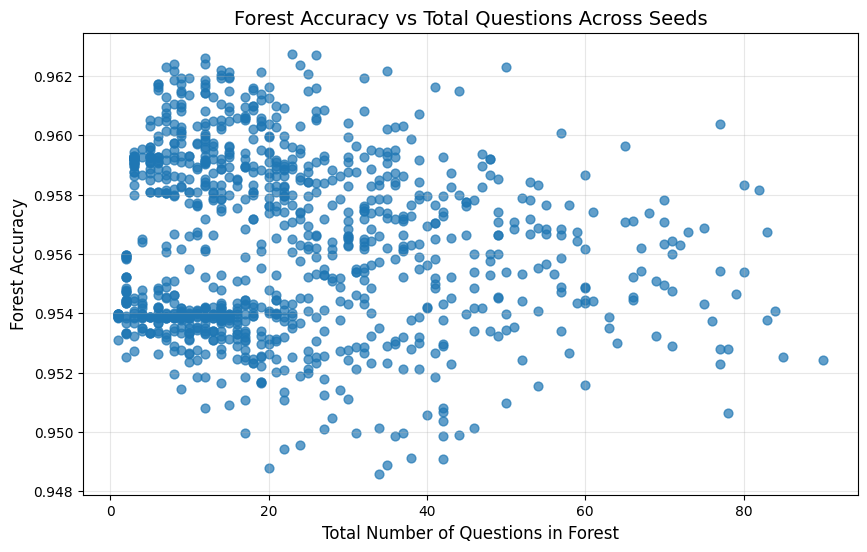

Saved plot as accuracy_vs_questions.jpg


<Figure size 640x480 with 0 Axes>

In [ ]:
# === New Cell: Load results and create scatter plot ===

import pandas as pd
import matplotlib.pyplot as plt

# 1) Read results
results_df = pd.read_csv("results.csv")

# 2) Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    results_df["total_questions"],
    results_df["forest_accuracy"],
    s=40,
    alpha=0.7
)

plt.xlabel("Total Number of Questions in Forest", fontsize=12)
plt.ylabel("Forest Accuracy", fontsize=12)
plt.title("Forest Accuracy vs Total Questions Across Seeds", fontsize=14)

plt.grid(True, alpha=0.3)

# Show inline
plt.show()

# 3) Save as JPG
plt.savefig("accuracy_vs_questions.jpg", dpi=300, bbox_inches="tight")

print("Saved plot as accuracy_vs_questions.jpg")


Best forest (based on 75% rule and minimal questions):
seed               256.000000
forest_accuracy      0.962306
n_trees              1.000000
total_questions      7.000000
Name: 256, dtype: float64

Rebuilt forest with seed=256
  Number of trees: 1
  Max questions per tree (constraint): 9


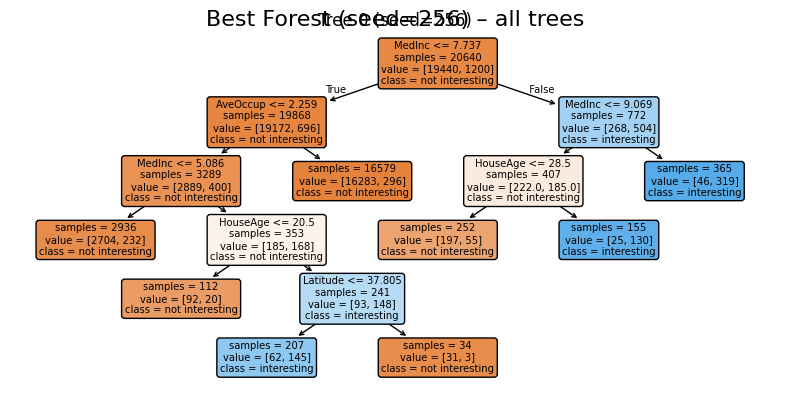

Saved forest visualization as best_forest_all_trees.jpg


In [ ]:
# === New Cell: Identify best forest and visualize all its trees ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import ceil
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.tree import _tree  # <-- added for pruning

# 1) Load the results
results_df = pd.read_csv("results.csv")

# 2) Find accuracy threshold: better than 75% of all models
acc_threshold = results_df["forest_accuracy"].quantile(0.99)

# Forests strictly better than 75% of all
top_df = results_df[results_df["forest_accuracy"] > acc_threshold]

# Fallback: if none strictly greater, allow >=
if top_df.empty:
    top_df = results_df[results_df["forest_accuracy"] >= acc_threshold]

# 3) Among these, choose the one with:
#    - smallest total_questions
#    - if tie: highest forest_accuracy
#    - if tie again: smallest seed
top_sorted = top_df.sort_values(
    by=["total_questions", "forest_accuracy", "seed"],
    ascending=[True, False, True]
)

best_row = top_sorted.iloc[0]
best_seed = int(best_row["seed"])

print("Best forest (based on 75% rule and minimal questions):")
print(best_row)


# --- added: same pruning helper as in training code ---
def prune_pure_subtrees(tree: DecisionTreeClassifier) -> None:
    """
    In-place pruning: if all leaves in a subtree predict the same class,
    collapse the whole subtree into a single leaf node without
    changing the tree's predictions.
    """
    tree_ = tree.tree_

    def recurse(node_id: int):
        # Leaf -> return its predicted class index
        if tree_.children_left[node_id] == -1 and tree_.children_right[node_id] == -1:
            value = tree_.value[node_id][0]
            class_index = int(np.argmax(value))
            return {class_index}

        # Recurse into children
        left_id = tree_.children_left[node_id]
        right_id = tree_.children_right[node_id]

        left_classes = recurse(left_id)
        right_classes = recurse(right_id)

        union = left_classes | right_classes

        # If all leaves below predict the same class, prune here
        if len(union) == 1:
            tree_.children_left[node_id] = -1
            tree_.children_right[node_id] = -1
            tree_.feature[node_id] = _tree.TREE_UNDEFINED
            tree_.threshold[node_id] = -2.0
            # Keep tree_.value[node_id] as-is; argmax stays consistent
        return union

    recurse(0)
# --- end added helper ---


# 4) Rebuild the forest for this seed (deterministically, same logic as training)
def rebuild_forest_for_seed(seed: int):
    """
    Rebuilds the forest for the given seed using the same logic
    as the training code, and returns the list of trees and the
    per-seed max_questions used.
    """
    rng = np.random.RandomState(seed)
    n_samples = X.shape[0]

    # Same per-seed maxima as in the training cell
    max_n_trees = rng.randint(1, 11)   # 1..10 inclusive
    max_questions = rng.randint(2, 11) # 2..10 inclusive

    n_trees = max_n_trees

    trees = []

    for tree_idx in range(n_trees):
        # Bootstrap sample
        bootstrap_indices = rng.choice(n_samples, size=n_samples, replace=True)
        X_boot = X[bootstrap_indices]
        y_boot = y[bootstrap_indices]

        # Same constraint: at most max_questions internal decision nodes
        tree_random_state = rng.randint(0, 1_000_000)
        clf = DecisionTreeClassifier(
            max_leaf_nodes=max_questions + 1,
            random_state=tree_random_state,
        )
        clf.fit(X_boot, y_boot)
        prune_pure_subtrees(clf)  # <-- added: prune to match training behavior
        trees.append(clf)

    return trees, max_questions


trees, max_questions = rebuild_forest_for_seed(best_seed)
n_trees = len(trees)

print(f"\nRebuilt forest with seed={best_seed}")
print(f"  Number of trees: {n_trees}")
print(f"  Max questions per tree (constraint): {max_questions}")


# 5) Visualize the entire forest (all trees) in one figure
if n_trees == 1:
    n_cols = 1
else:
    n_cols = 2  # up to 2 trees per row for readability
n_rows = ceil(n_trees / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 4 * n_rows))

# Make axes iterable in a flat array
if n_trees == 1:
    axes = np.array([axes])
else:
    axes = np.array(axes).reshape(-1)

for idx, (clf, ax) in enumerate(zip(trees, axes)):
    plot_tree(
        clf,
        feature_names=feature_cols,
        class_names=["not interesting", "interesting"],
        filled=True,
        rounded=True,
        impurity=False,
        ax=ax
    )
    ax.set_title(f"Tree {idx} (seed={best_seed})")

# Hide any unused axes (if n_trees is odd)
for ax in axes[n_trees:]:
    ax.axis("off")

fig.suptitle(f"Best Forest (seed={best_seed}) – all trees", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Save as JPG
plt.savefig("best_forest_all_trees.jpg", dpi=300, bbox_inches="tight")

# Show inline
plt.show()

print("Saved forest visualization as best_forest_all_trees.jpg")


Best forest (from results.csv):
seed               256.000000
forest_accuracy      0.962306
n_trees              1.000000
total_questions      7.000000
Name: 256, dtype: float64

Found 1 trees for forest with seed=256.

Rendering tree 0...


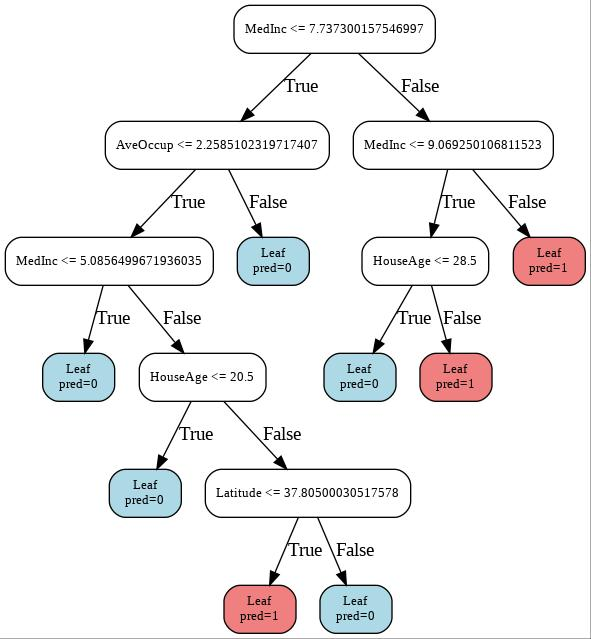

Saved tree 0 → best_forest_seed256_tree0.jpg


In [ ]:
# === New Cell: Identify best forest & visualize YAML trees using Graphviz ===

import importlib
import subprocess
import sys

# -----------------------------------------------------------
# 0) Check if Graphviz is installed — install only if needed
# -----------------------------------------------------------
need_install = False
try:
    import graphviz
except ImportError:
    need_install = True

if need_install:
    print("Graphviz not found — installing...")
    # Install OS-level graphviz first
    subprocess.run(["apt-get", "update"])
    subprocess.run(["apt-get", "install", "-y", "graphviz"])
    # Install Python package
    subprocess.run([sys.executable, "-m", "pip", "install", "graphviz"])

# After installation, import again
import graphviz
from graphviz import Digraph

import pandas as pd
import numpy as np
import yaml
import os
from math import ceil
from IPython.display import Image, display


# -----------------------------------------------------------
# 1) Load forest-level results
# -----------------------------------------------------------
results_df = pd.read_csv("results.csv")

# 2) Determine accuracy threshold (75%)
acc_threshold = results_df["forest_accuracy"].quantile(0.99)

# Forests strictly above threshold
top_df = results_df[results_df["forest_accuracy"] > acc_threshold]
if top_df.empty:
    # fallback: allow >=
    top_df = results_df[results_df["forest_accuracy"] >= acc_threshold]

# 3) Pick best forest using:
#    lowest total_questions → highest accuracy → lowest seed
top_sorted = top_df.sort_values(
    by=["total_questions", "forest_accuracy", "seed"],
    ascending=[True, False, True]
)

best_row = top_sorted.iloc[0]
best_seed = int(best_row["seed"])

print("Best forest (from results.csv):")
print(best_row)


# -----------------------------------------------------------
# 4) Load *all* YAML trees for this best forest
# -----------------------------------------------------------
yaml_files = sorted(
    f for f in os.listdir(".")
    if f.startswith(f"tree_seed{best_seed}_tree") and f.endswith(".yml")
)

trees_yaml = []
for fname in yaml_files:
    with open(fname, "r") as fh:
        trees_yaml.append(yaml.safe_load(fh))

n_trees = len(trees_yaml)
print(f"\nFound {n_trees} trees for forest with seed={best_seed}.")


# -----------------------------------------------------------
# 5) Build a Graphviz graph from YAML
# -----------------------------------------------------------
def build_graphviz_from_yaml(tree_yaml, name="tree"):
    """
    Convert YAML tree structure into a Graphviz Digraph.

    Coloring rules:
      - Internal node = white
      - Leaf pred=0 (non-interesting) = blue
      - Leaf pred=1 (interesting)     = red
    """
    dot = Digraph(name=name)
    dot.attr("node", shape="box", style="filled,rounded", fontsize="10")

    node_counter = [0]

    def next_id():
        nid = f"n{node_counter[0]}"
        node_counter[0] += 1
        return nid

    def recurse(node):
        nid = next_id()

        # Leaf
        if "leaf_prediction" in node:
            pred = node["leaf_prediction"]
            label = f"Leaf\npred={pred}"

            if pred == 0:
                fillcolor = "lightblue"
            else:
                fillcolor = "lightcoral"

            dot.node(nid, label=label, fillcolor=fillcolor)
            return nid

        # Internal decision node
        question = node.get("question", "")
        dot.node(nid, label=question, fillcolor="white")

        left_id = recurse(node["left"])
        right_id = recurse(node["right"])

        dot.edge(nid, left_id, label="True")
        dot.edge(nid, right_id, label="False")

        return nid

    recurse(tree_yaml)
    return dot


# -----------------------------------------------------------
# 6) Visualize all trees in the forest
# -----------------------------------------------------------
all_images = []

for idx, tree_yaml in enumerate(trees_yaml):
    print(f"\nRendering tree {idx}...")

    dot = build_graphviz_from_yaml(tree_yaml, name=f"bestforest_seed{best_seed}_tree{idx}")
    dot.format = "jpg"

    out_name = f"best_forest_seed{best_seed}_tree{idx}"
    filename = dot.render(out_name, cleanup=True)  # creates out_name + ".jpg"

    display(Image(filename))
    print(f"Saved tree {idx} → {filename}")
